1. ĐANG LOAD DỮ LIỆU...
✅ X_train shape: (4852, 20) | y_train phân bố: 55.4% Home Win
✅ X_test shape:  (1209, 20)  | y_test phân bố:  55.3% Home Win

2. ĐANG HUẤN LUYỆN MÔ HÌNH...
✅ Huấn luyện xong!

3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)
--- Mô hình: Logistic Regression Baseline ---
Accuracy : 0.6766 (Độ chính xác tổng thể)
ROC-AUC  : 0.7288 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7193

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.65      0.59      0.62       540
Home Win (1)       0.69      0.75      0.72       669

    accuracy                           0.68      1209
   macro avg       0.67      0.67      0.67      1209
weighted avg       0.67      0.68      0.67      1209



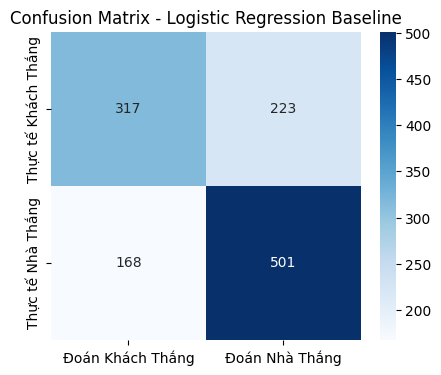



--- Mô hình: XGBoost Classifier ---
Accuracy : 0.6782 (Độ chính xác tổng thể)
ROC-AUC  : 0.7242 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7239

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.66      0.57      0.61       540
Home Win (1)       0.69      0.76      0.72       669

    accuracy                           0.68      1209
   macro avg       0.68      0.67      0.67      1209
weighted avg       0.68      0.68      0.68      1209



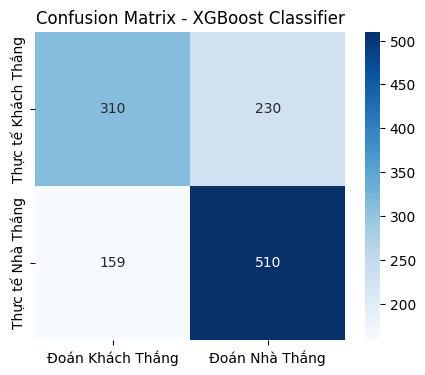


4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)


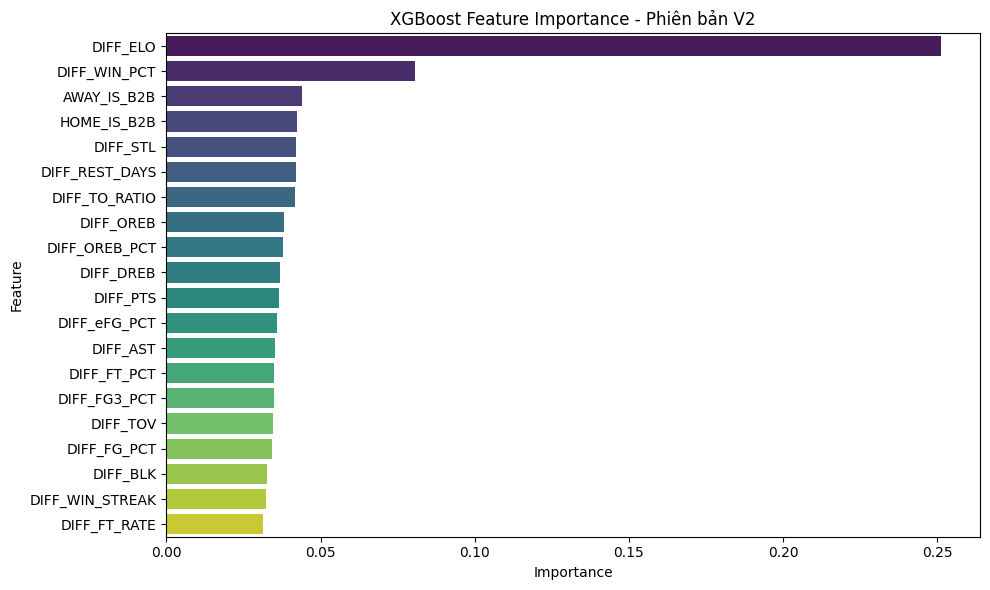

In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# 1. Đọc file cấu hình và dữ liệu
print("1. ĐANG LOAD DỮ LIỆU...")
try:
    with open(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V2\output\feature_config_v2.json', 'r', encoding='utf-8') as f:
        config = json.load(f)
    FEATURES = config['feature_set_v2']
    LABEL = config['label']
except FileNotFoundError:
    print("⚠️ Không tìm thấy file JSON. Đang dùng danh sách thủ công...")
    FEATURES = ['DIFF_PTS', 'DIFF_FG_PCT', 'DIFF_FG3_PCT', 'DIFF_FT_PCT', 'DIFF_OREB', 
                'DIFF_DREB', 'DIFF_AST', 'DIFF_STL', 'DIFF_BLK', 'DIFF_TOV', 
                'DIFF_WIN_PCT', 'DIFF_WIN_STREAK', 'DIFF_REST_DAYS', 'HOME_IS_B2B', 'AWAY_IS_B2B']
    LABEL = 'HOME_WIN'

train_df = pd.read_csv(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V2\output\eval_train_v2.csv')
test_df = pd.read_csv(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V2\output\eval_test_v2.csv')

X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test, y_test = test_df[FEATURES], test_df[LABEL]

print(f"✅ X_train shape: {X_train.shape} | y_train phân bố: {y_train.mean():.1%} Home Win")
print(f"✅ X_test shape:  {X_test.shape}  | y_test phân bố:  {y_test.mean():.1%} Home Win\n")

# 2. Huấn luyện mô hình Baseline (Logistic Regression) và XGBoost
print("2. ĐANG HUẤN LUYỆN MÔ HÌNH...")

# Mô hình 1: Logistic Regression (Rất tốt để làm baseline cho bài toán thể thao)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Mô hình 2: XGBoost (Thuật toán Tree-based mạnh nhất)
xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=4,        
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("✅ Huấn luyện xong!\n")

# 3. Đánh giá mô hình trên tập Test (Mùa 2025-26)
print("3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)")
print("="*60)

def evaluate_model(name, model, X, y_true):
    # Dự đoán nhãn (0/1) và xác suất (0.0 -> 1.0)
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    # Tính các metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print(f"--- Mô hình: {name} ---")
    print(f"Accuracy : {acc:.4f} (Độ chính xác tổng thể)")
    print(f"ROC-AUC  : {auc:.4f} (Khả năng phân tách Thắng/Thua)")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Away Win (0)', 'Home Win (1)']))
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Đoán Khách Thắng', 'Đoán Nhà Thắng'], 
                yticklabels=['Thực tế Khách Thắng', 'Thực tế Nhà Thắng'])
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    
    return model

# Gọi hàm đánh giá
evaluate_model("Logistic Regression Baseline", lr_model, X_test, y_test)
print("\n")
evaluate_model("XGBoost Classifier", xgb_model, X_test, y_test)

# 4. Phân tích Feature Importance của XGBoost
print("\n4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)")
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('XGBoost Feature Importance - Phiên bản V2')
plt.tight_layout()
plt.show()

# So sánh V1 và V2

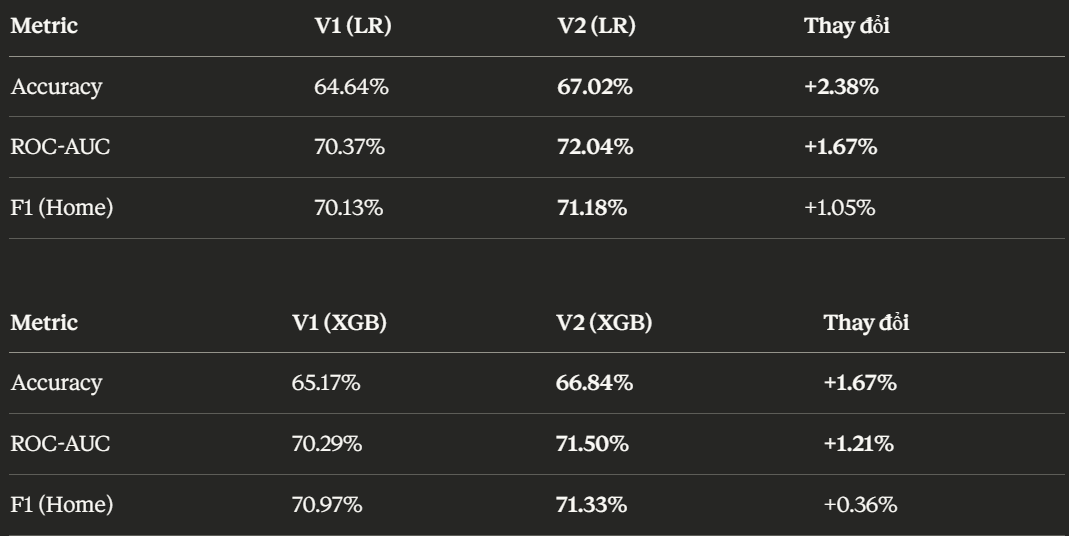

**1. Điểm yếu 1 - Recall Away Win**
- V1: 50-51% -> V2: 57-58% -> cải thiện đáng kể. Elo đang giúp model nhận ra khi nào đội khách thực sự mạnh hơn
- Nhận xét:
    - Logistic Regression bây giờ tốt hơn XGBoost — điều này hợp lý vì 20 features đều là DIFF (đã encode sẵn quan hệ tuyến tính), LR tận dụng tốt hơn. XGBoost có thể cần tune thêm hoặc chưa đủ data để phát huy tree-based.
    - Recall Away Win vẫn thấp hơn Home Win (58% vs 74-75%), nhưng gap đã thu hẹp nhiều so với V1 (50% vs 74%).

- Tại sao 4 Oliver's Factor không quá mạnh ?
    - Tính bao trùm của Elo: `DIFF_ELO` và `DIFF_WIN_PCT` là những biến vĩ mô (macro). Chúng giống như thực thể tổng hợp đã hấp thụ toàn bộ sức mạnh của 4 Factors. Một đội bóng không thể có hệ số Elo cao ngất ngưởng nếu họ không ném rổ tốt (eFG%), không kiểm soát bóng tốt (TOV%) hoặc không rebound tốt. Thuật toán XGBoost có bản chất greedy. Khi tìm kiếm điểm chia nhánh (split), nếu `DIFF_ELO` mang lại IG lớn, nó sẽ được chọn làm root node. Điều này vô tình che khuất đi các chỉ số micro
    - Vấn đề về Matchup (Tính đối kháng trực tiếp): Chỉ số trung bình của 4 Factors đại diện cho đội A đã thi đấu như thế nào với phần còn lại của giải đấu, chứ không phản ánh việc họ sẽ đối đầu ra sao với đội B tối nay
        - Ví dụ, đội A có `OREB%` cực kỳ cao vì họ vừa gặp một loạt các đội bóng nhỏ con. Nhưng tối này đói thủ của họ lại rất đô con, lúc này chỉ số `OREB%` gần như mất đi sức mạnh dự báo
        

    